# Import libraries

In [116]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.mixture import GaussianMixture

# Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Hierarchical clustering 
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset

In [117]:
df = pd.read_csv('../datasets/Mall_Customers.csv')

# Dataset exploration

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [119]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Checking missing vales

In [121]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Exploratory Data Analysis (EDA)

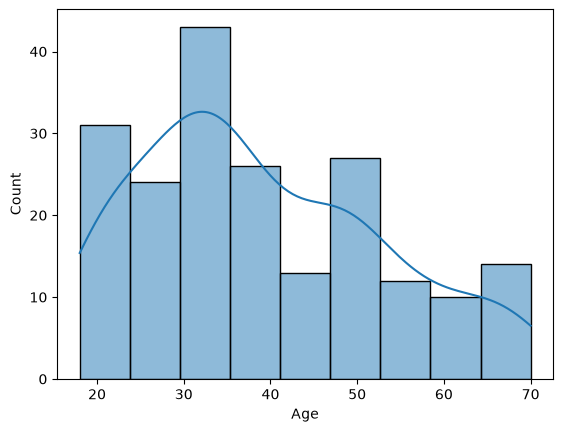

In [122]:
# Distribution of age
sns.histplot(df['Age'], kde=True)
plt.show()

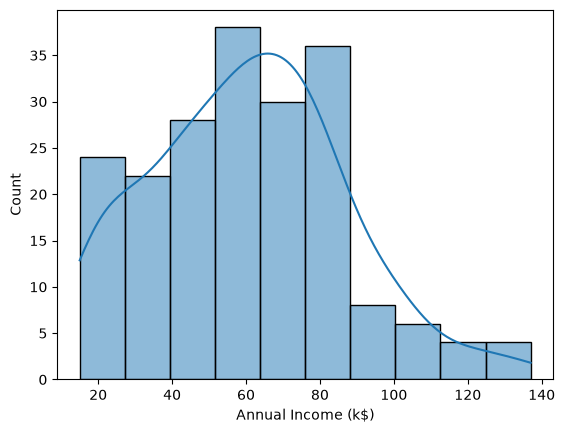

In [123]:
# Distribution of Annual Income
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.show()

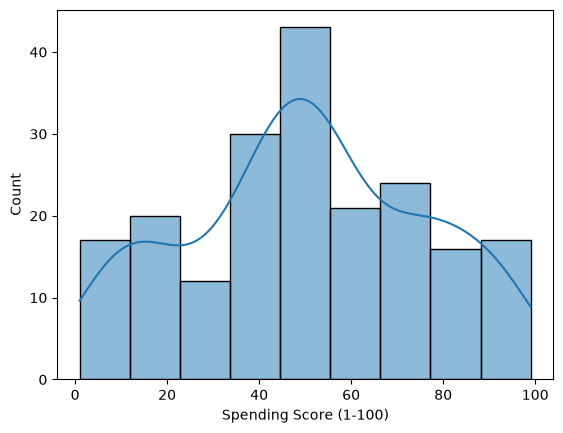

In [124]:
# Distribution of Spending Score
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.show()

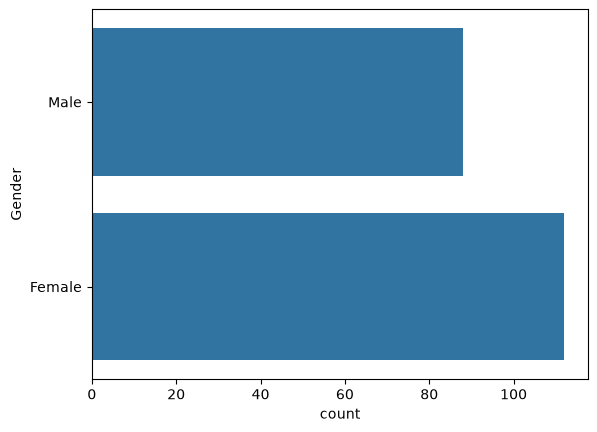

In [125]:
# Gender count
sns.countplot(df['Gender'])
plt.show()

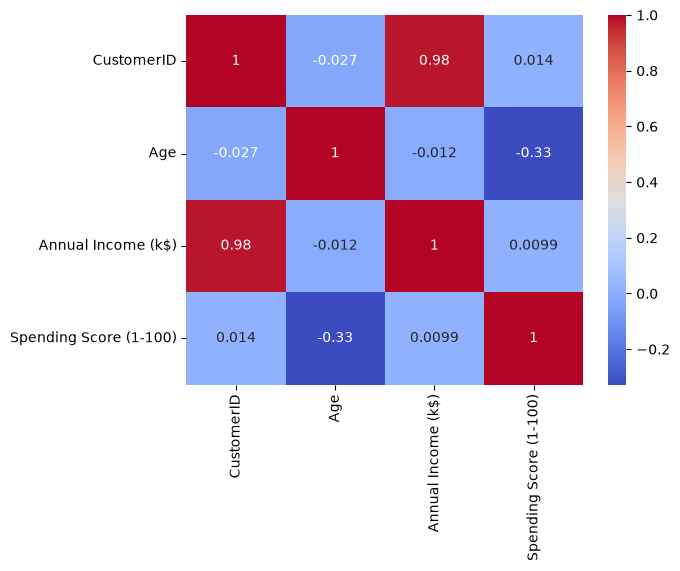

In [126]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

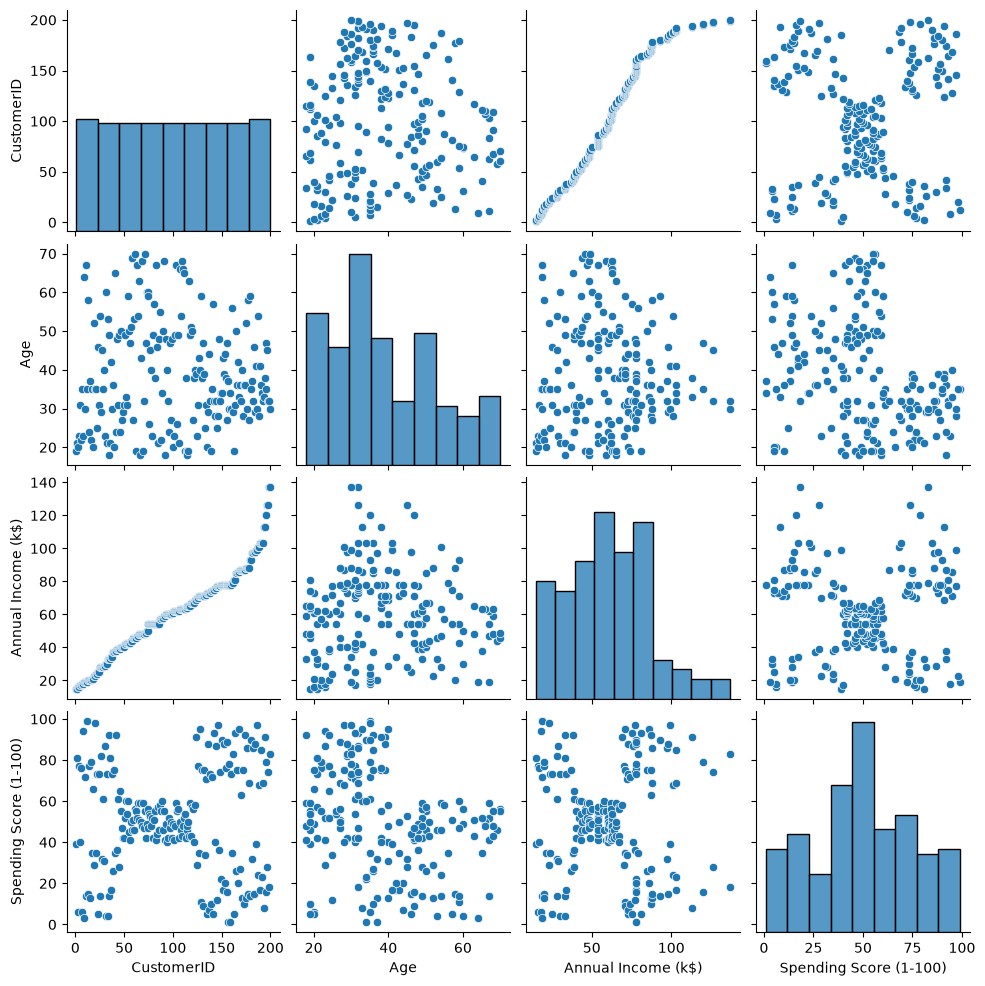

In [127]:
# Pair plot
sns.pairplot(df)
plt.show()

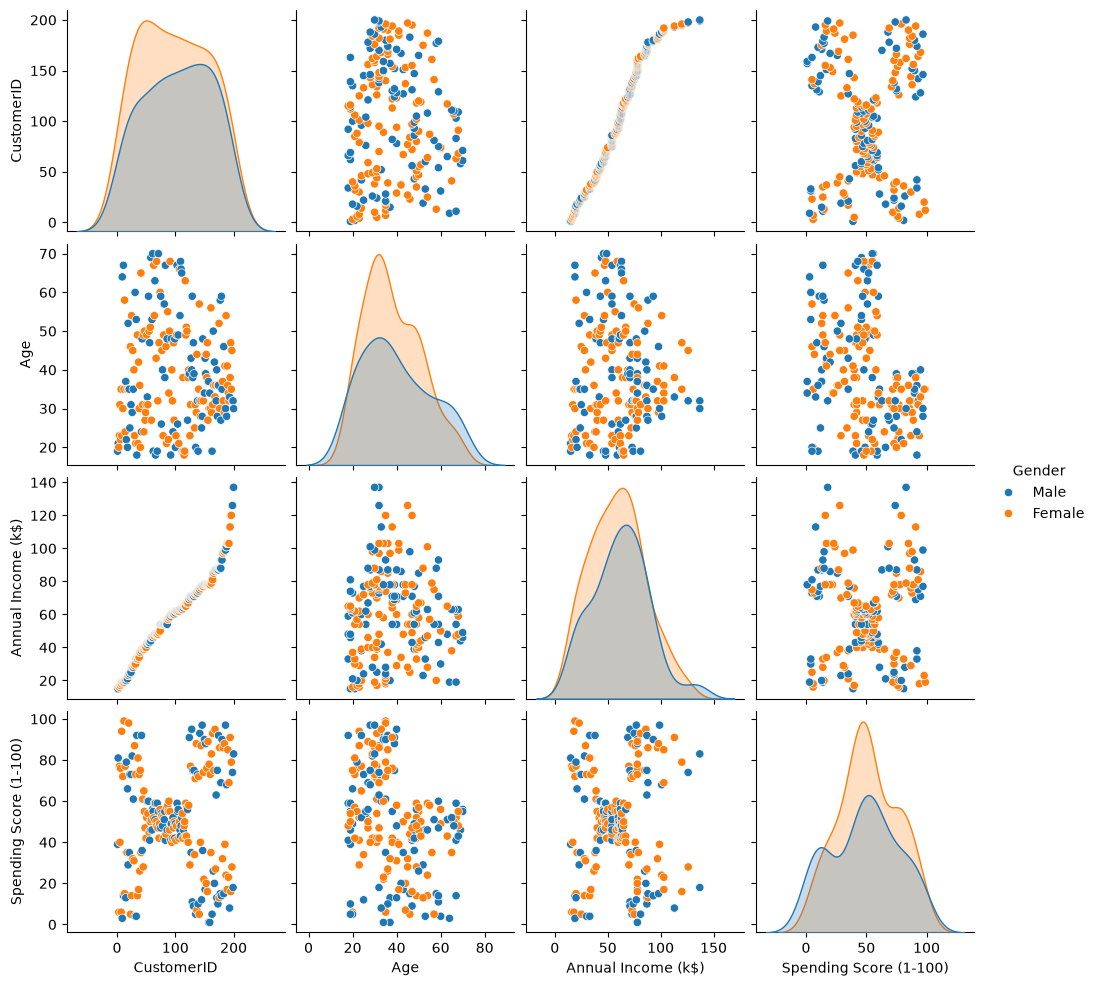

In [128]:
# Pair plot by Gender
sns.pairplot(df, hue="Gender")
plt.show()

# Feature Selections

In [129]:
# Feature seletion
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Feature Scalling

In [130]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method (K-Means)

The elbow method lets us graph the inertia (a distance-based metric) and visualize the point at which it starts decreasing linearly.

In [131]:
# Elbow Method (K-Means)
inertias = []

for k in range (1,20):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)


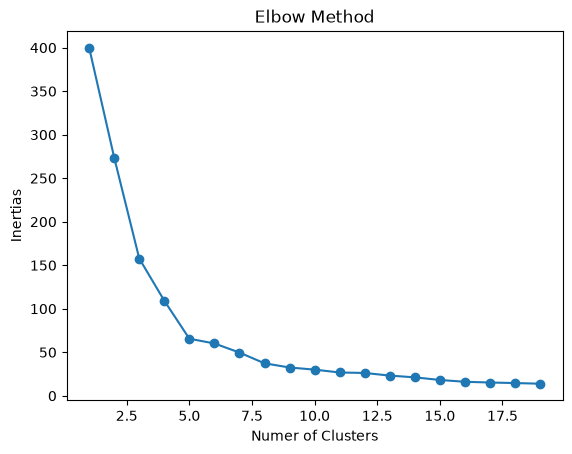

In [132]:
# Plot
plt.Figure(figsize=(8,3))
plt.plot(range(1,20), inertias, marker="o")
plt.xlabel("Numer of Clusters")
plt.ylabel("Inertias")
plt.title("Elbow Method")
plt.show()

The elbow method shows that 5 is a good value for K.

KMeans Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


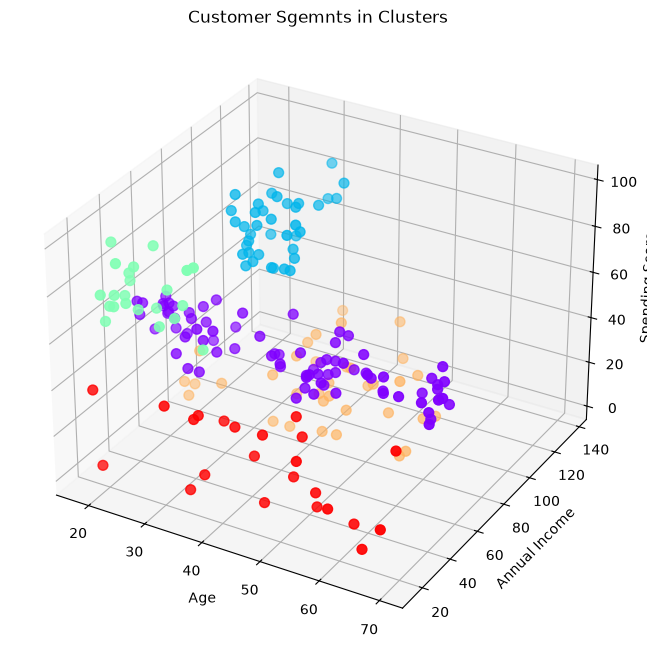

In [133]:
# n_cluster = 5
best_model = KMeans(n_clusters=5, random_state=42)
df['KMeans Cluster'] = best_model.fit_predict(X_scaled)
print(df['KMeans Cluster'].value_counts())

#plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=model.labels_)
#plt.show()

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['KMeans Cluster'], cmap='rainbow', s=50)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')
plt.title('Customer Sgemnts in Clusters')
plt.show()

# Silhouette analysis (K-Means)

Silhouette analysis measures how well-separated your data clusters are. It evaluates each point based on how close it is to its own cluster (cohesion) versus how far it is from neighboring clusters (separation).

In [134]:
# Silhoiette Score
silhouette_score = silhouette_score(X_scaled, df['KMeans Cluster'])
print(silhouette_score)

0.5546571631111091


Interpretation of Your Silhouette Score (0.5547):
0.5547 is a moderate score. It indicates that the clusters are reasonably well separated, but there may still be some overlap between clusters.

# Hierarchical Clustering

It is an unsupervised machine learning algorithm that groups data into a tree-like hierarchy of nested clusters. 

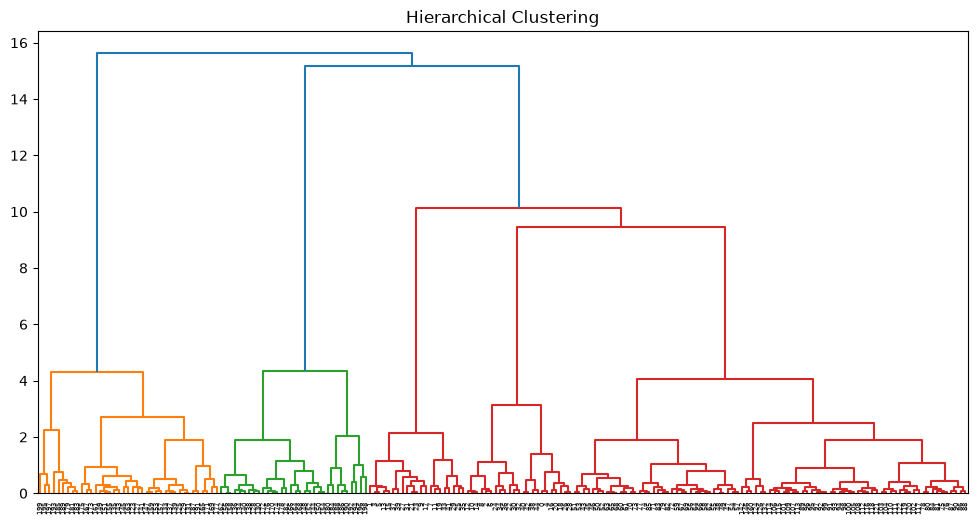

In [135]:
# Hierarchical Clustering
# Ward's Linkage: Minimizes the variance within each cluster, functioning similarly to K-Means.
linkage  =linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linkage)
plt.title("Hierarchical Clustering")
plt.show()

# Agglomerative Clustering (Bottom-Up).  The most common method. It begins by treating every data point as a single cluster and progressively merges the closest clusters together until all data falls into one large cluster.

In [136]:
hierarchical = AgglomerativeClustering(n_clusters=5)
df['Hierarchical'] = hierarchical.fit_predict(X_scaled)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

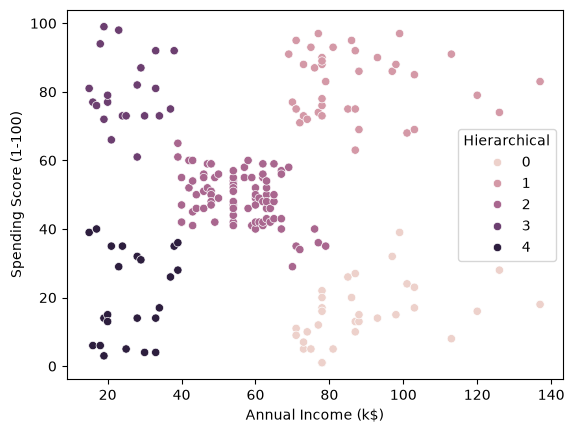

In [137]:
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Hierarchical"
)

# DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised machine learning algorithm that groups data points based on their density. Unlike K-Means, it finds clusters of arbitrary shapes and automatically detects outliers, without requiring you to specify the number of clusters in advance.

In [138]:
# DBSCAN
# ε (Epsilon): The maximum radius of the neighborhood around a data point.
# MinPts: The minimum number of data points required to exist within the ε radius to form a dense region.
dbscan = DBSCAN (eps=0.5, min_samples=5)

df['DBSCAN'] = dbscan.fit_predict(X_scaled)


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

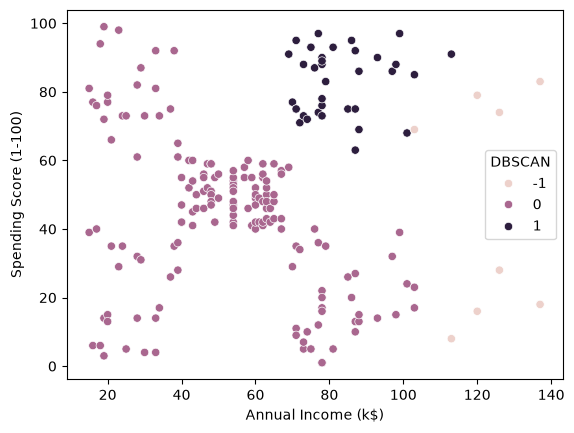

In [139]:
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="DBSCAN"
)

DBSCAN classifies data into Core point, Border point, and Noise. A data point is a Core point if the circle around it contains at least ‘minPoints’ number of points. If the number of points is less than minPoints, then it is classified as Border Point, and if there are no other data points around any data point within epsilon radius, then it treated as Noise.
Here -1 indicates the noise points.

# Gaussian Mixture Model

A Gaussian Mixture Model (GMM) is a probabilistic unsupervised machine learning algorithm that assumes data points are generated from a mixture of several Gaussian distributions. 

In [ ]:
# Gaussian Mixture Model
# Cluster Shape: K-Means assumes spherical clusters. 
# GMM utilizes covariance matrices, allowing it to model elliptical shapes and clusters of different sizes.
gmm = GaussianMixture(n_components=5, random_state=42)

df['GMM'] = gmm.fit_predict(X_scaled)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

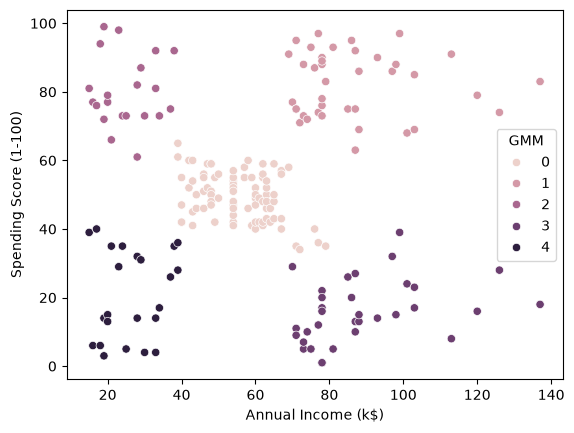

In [142]:
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="GMM"
)

# Cluster Evaluation

In [ ]:
def evaluate(name, labels):
    print(name)
    print("Silhouette:",silhouette_score(X_scaled, labels))
    print( "Davies-Bouldin:", davies_bouldin_score(X_scaled,labels))
    print( "Calinski-Harabasz:", calinski_harabasz_score(X_scaled, labels))
